# 2022-037 Runx3-mut Experiment

Re-analysis of original mutants experiment. The original flow files are in
`OneDrive - The Scripps Research Institute\Lab 2021\Flow\Albao2022-11-28-Runx3Mut-Day8`

### Initialize environment:

In [1]:
# Load R Packages
library(fcexpr) # Reads FlowJo Workspace files
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)


Attaching package: ‘ggpubr’




The following object is masked from ‘package:cowplot’:

    get_legend





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig04")

# Load flow processing functions (plot_padj for multiple-hypothesis-corrected comparisons)
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load processed data
load("2022-037-PercentPop-MFI.RData")

# List environment
ls()


Attaching package: ‘rstatix’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘purrr’




The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




Warning message:
“namespace ‘ggvenn’ is not available and has been replaced
by .GlobalEnv when processing object ‘p3’”


[1] "add_population_derivatives" "batch"                     
 [3] "combinePercents"            "compute_percent_of_total"  
 [5] "counts"                     "de"                        
 [7] "de.null"                    "design"                    
 [9] "down"                       "finalize_flow_table"       
[11] "fit.mt"                     "fit.mt.2"                  
[13] "fit.mt.null"                "fit.mt.null.2"             
[15] "i"                          "load_workspace_cached"     
[17] "macor"                      "macor.norm"                
[19] "markers"                    "markers.cor"               
[21] "markers.norm"               "markers.spread"            
[23] "mfi"                        "mfi.ba"                    
[25] "mfi.ba.norm"                "mfi.meta"                  
[27] "mfi.mt"                     "mfi.mt.norm"               
[29] "mfi.ra"                     "mfi.ra.norm"               
[31] "mfi.wt"                     "muts"                      
[33] "nc"                         "p1"                        
[35] "p2"                         "p3"                        
[37] "pca.ba"                     "pca.macor"                 
[39] "pca.markers"                "pca.mt"                    
[41] "pca.ra"                     "plot_padj"                 
[43] "pops"                       "populationPlot"            
[45] "ratios"                     "start"                     
[47] "startingRatios"             "stats"                     
[49] "subsets"                    "umap.ba"                   
[51] "umap.ba.df"                 "umap.macor"                
[53] "umap.markers"               "umap.mt"                   
[55] "umap.mt.df"                 "umap.ra"                   
[57] "umap.ra.df"                 "up"                        
[59] "venn.down"                  "venn.nc"                   
[61] "venn.up"                    "workspace"

In [3]:
head(subsets)

,Identifier,Setup,Subset,MT,WT,temp
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,AD1,AD,DP,3.825986,16.09694,AD1
2,AD1,AD,EE,9.700913,17.98698,AD1
3,AD1,AD,MP,2.884055,13.77283,AD1
4,AD1,AD,Tcm,4.661099,16.44963,AD1
5,AD1,AD,TE,83.589046,52.14324,AD1
6,AD1,AD,Tem,79.918431,36.03274,AD1


In [4]:
# Check if all temp is Identifier (one-to-one)
all(subsets$Identifier == subsets$Temp)

[1] TRUE

In [5]:
# Remove temp, rename Identifier to ID
subsets <- subsets %>%
  select(-temp) %>%
  rename(ID = Identifier)

# Check groups
table(subsets$Setup)
table(mfi$Subset)


  AD   ID Null   VW   WT 
  35   35   35   35   35 

< table of extent 0 >

In [6]:
# Rename Setup Null into mock
# and add a prefix d to AD, ID, and rename VW to dVWRPY
subsets$Setup <- gsub("Null", "mock", subsets$Setup)
subsets$Setup <- gsub("AD", "dAD", subsets$Setup)
subsets$Setup <- gsub("ID", "dID", subsets$Setup)
subsets$Setup <- gsub("VW", "dVWRPY", subsets$Setup)
subsets$Setup <- gsub("WT", "Runx3-WT", subsets$Setup)
# Factorize
subsets$Setup <- factor(subsets$Setup,
                        levels = c("mock", "Runx3-WT", "dAD", "dID", "dVWRPY"))

In [7]:
# Factorize Subset
subsets$Subset <- factor(   subsets$Subset,
                            levels = c("TE", "EE", "DP", "MP",
                                "Tcm", "Tpm", "Tem"))

In [8]:
# Create a default theme
colors <- c("mock" = "#808180",
            "Runx3-WT" = "#00A087",
            "dAD" = "#3C5488",
            "dID"= "#F39B7F",
            "dVWRPY" = "#4DBBD5")

# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans",
                        #base_fontface = "plain"
                        ) +
    theme(  axis.text = element_text(size = 10),
            axis.title = element_text(size = 12),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 12),
            axis.title.x = element_blank(),
            strip.text = element_text(size = 12),
            strip.background = element_blank(),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

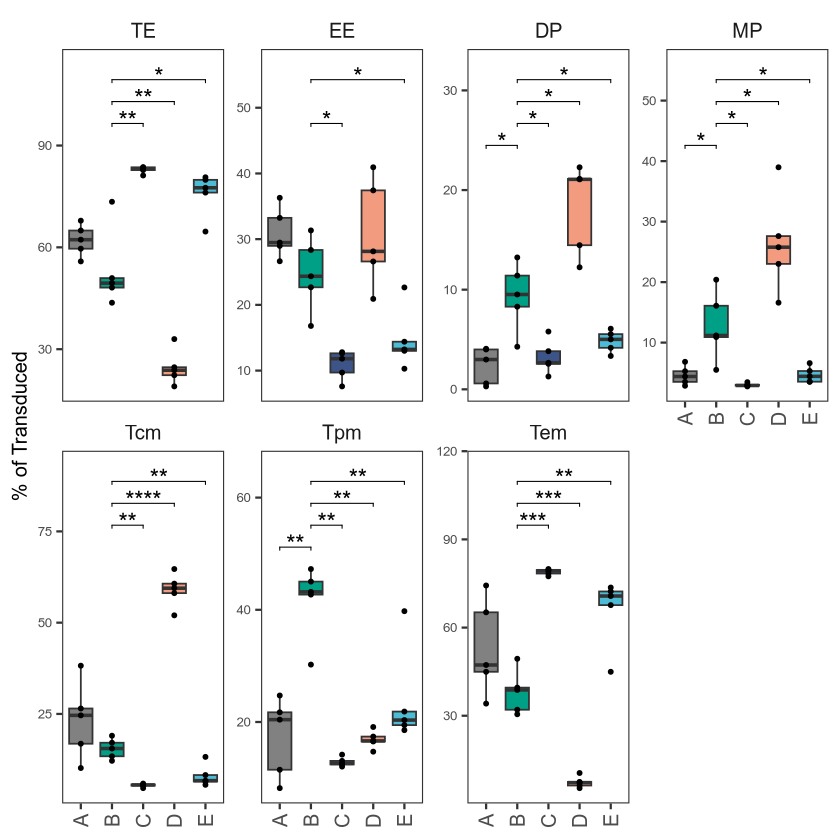

In [9]:
# Calculate p-values and BH-adjusted p-values for comparisons using plot_padj function
plot.stat.df <- plot_padj(
    data = subsets,
    comparisons = list(
        c("mock", "Runx3-WT"),
        c("Runx3-WT", "dAD"),
        c("Runx3-WT", "dID"),
        c("Runx3-WT", "dVWRPY")
    ),
    y_col = "MT",
    x_col = "Setup",
    facet_col = "Subset",
    paired = FALSE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2022-037-Runx3mut-MT-stats.csv", row.names = FALSE)

# Only the significant comparisons get a bracket drawn (see
# stat_pvalue_manual below), so only these need extra headroom
plot.stat.sig <- plot.stat.df %>% filter(p.adj < 0.05)

p <- ggplot(subsets, aes(x = Setup, y = MT, fill = Setup)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size = 1) +
    facet_wrap(~ Subset, ncol = 4, scales = "free_y") +  # Set number of columns

    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "A", 
                                "Runx3-WT" = "B", 
                                "dAD" = "C", 
                                "dID" = "D", 
                                "dVWRPY" = "E")) +
    ylab("% of Transduced") +
    theme +
    # Make room for the p-value bracket: with scales = "free_y", each panel
    # auto-scales to subsets alone, so the bracket drawn at y.position
    # (above the tallest box, per plot_padj()'s step_fraction/min_step) would
    # get clipped at the top of the panel without this. geom_blank() is
    # invisible but still trains the y-scale, and a small multiplier adds
    # headroom for the label text sitting above the bracket line itself.
    geom_blank( data = plot.stat.sig, aes(x = group1, y = y.position),
                inherit.aes = FALSE) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.10))) +
    stat_pvalue_manual(
        plot.stat.sig,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    theme(  #strip.text = element_blank(),
            axis.text = element_text(size = 8))

#pdf("Test2.pdf")
print(p)

In [10]:
pdf("MutPhenotype3.pdf", width = 5, height = 4)
print(p)
dev.off()

pdf 
  2

In [11]:
mfi

Identifier,Setup,Population,CD103,CD127,CD25,CD27,CD44,CD62L,CX3CR1,CXCR3,CXCR5,GranzymeB,KLRG1,LAG3,PD1,Tbet,Tcf7,Tim3,TOX
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AD1,AD,MT,17.70119,164.2163,121.80809,302.3486,1244.7513,188.50810,4516.4082,310.2549,402.2913,185.4393,1178.4763,120.4493,108.38286,88.65620,343.4158,181.92218,225.1865
AD1,AD,WT,24.76006,288.9933,167.03964,404.2204,1039.8186,142.46208,1826.0240,459.9283,380.4629,189.0633,616.9657,150.1145,216.03583,91.50552,465.3384,245.71370,213.1994
AD2,AD,MT,52.38157,177.4265,89.81683,338.6221,1485.2236,383.66104,4099.2285,461.8370,613.9478,347.1501,1232.6245,133.1266,129.07283,118.93352,244.5381,349.16870,348.9489
AD2,AD,WT,71.23898,382.9178,136.94218,423.6675,1312.9141,244.96373,1291.5751,517.3441,560.3257,350.2294,567.0109,164.5376,272.44186,78.34924,255.6715,423.17731,291.4544
AD3,AD,MT,36.38639,127.4731,67.02293,339.9377,1304.7523,168.41447,4583.8350,333.2116,437.3098,188.7682,1087.5743,119.7974,125.75191,98.78992,147.0542,153.25911,235.8611
AD3,AD,WT,45.96875,236.2337,93.03232,424.3051,1192.3844,117.24166,2026.7638,461.7813,370.2110,190.1602,539.9502,139.7993,232.23021,68.08014,142.3436,211.78625,181.9924
AD4,AD,MT,24.21394,144.2072,71.37281,334.4286,1539.9867,181.58099,4435.9141,325.9977,397.3229,154.1686,1140.5890,125.6239,134.32704,104.52051,165.3488,157.05989,229.4605
AD4,AD,WT,35.15070,252.5714,111.00588,426.7011,1196.0985,124.00726,1715.2638,432.8081,364.2975,171.2762,552.5305,144.6701,249.13824,74.92181,167.9910,221.02417,195.0904
AD5,AD,MT,21.26273,132.3413,61.46722,318.8202,1359.6886,134.62315,4694.1172,285.3159,318.7894,140.2750,1021.1650,113.9081,130.23238,104.18754,162.0643,128.56360,237.7437


In [12]:
# Rename Setup Null into mock
# and add a prefix d to AD, ID, and rename VW to dVWRPY
mfi$Setup <- gsub("Null", "mock", mfi$Setup)
mfi$Setup <- gsub("AD", "dAD", mfi$Setup)
mfi$Setup <- gsub("ID", "dID", mfi$Setup)
mfi$Setup <- gsub("VW", "dVWRPY", mfi$Setup)
mfi$Setup <- gsub("WT", "Runx3-WT", mfi$Setup)
# Factorize
mfi$Setup <- factor(mfi$Setup,
                    levels = c("mock", "Runx3-WT", "dAD", "dID", "dVWRPY"))

In [13]:
mfi <- mfi[mfi$Population == "MT", ]

In [14]:
mfi

,Identifier,Setup,Population,CD103,CD127,CD25,CD27,CD44,CD62L,CX3CR1,CXCR3,CXCR5,GranzymeB,KLRG1,LAG3,PD1,Tbet,Tcf7,Tim3,TOX
,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AD1,dAD,MT,17.70119,164.2163,121.80809,302.3486,1244.7513,188.50810,4516.4082,310.2549,402.2913,185.4393,1178.4763,120.4493,108.38286,88.65620,343.4158,181.92218,225.1865
3,AD2,dAD,MT,52.38157,177.4265,89.81683,338.6221,1485.2236,383.66104,4099.2285,461.8370,613.9478,347.1501,1232.6245,133.1266,129.07283,118.93352,244.5381,349.16870,348.9489
5,AD3,dAD,MT,36.38639,127.4731,67.02293,339.9377,1304.7523,168.41447,4583.8350,333.2116,437.3098,188.7682,1087.5743,119.7974,125.75191,98.78992,147.0542,153.25911,235.8611
7,AD4,dAD,MT,24.21394,144.2072,71.37281,334.4286,1539.9867,181.58099,4435.9141,325.9977,397.3229,154.1686,1140.5890,125.6239,134.32704,104.52051,165.3488,157.05989,229.4605
9,AD5,dAD,MT,21.26273,132.3413,61.46722,318.8202,1359.6886,134.62315,4694.1172,285.3159,318.7894,140.2750,1021.1650,113.9081,130.23238,104.18754,162.0643,128.56360,237.7437
11,ID1,dID,MT,41.25401,416.4870,121.86023,406.6869,1725.0243,119.26122,412.4809,824.2720,501.7928,253.5358,328.1349,160.7711,130.15007,66.53542,158.0255,178.86800,326.4417
13,ID2,dID,MT,37.77295,355.5566,123.29443,415.7222,1762.6255,116.05377,393.9192,792.1727,509.9110,218.9537,258.8633,172.2381,159.59209,77.55362,179.8730,208.90726,397.6548
15,ID3,dID,MT,64.01031,353.6392,163.63641,549.8920,1617.6444,210.81439,429.4168,1037.2566,834.1688,362.9614,408.5675,185.6323,211.07257,70.09940,181.9462,239.13956,402.5672
17,ID4,dID,MT,36.47086,316.3389,119.23748,427.9944,1787.3357,124.13387,392.7605,793.5419,493.1710,229.2581,261.0885,166.7581,180.24371,75.09985,171.0236,207.82069,380.3432


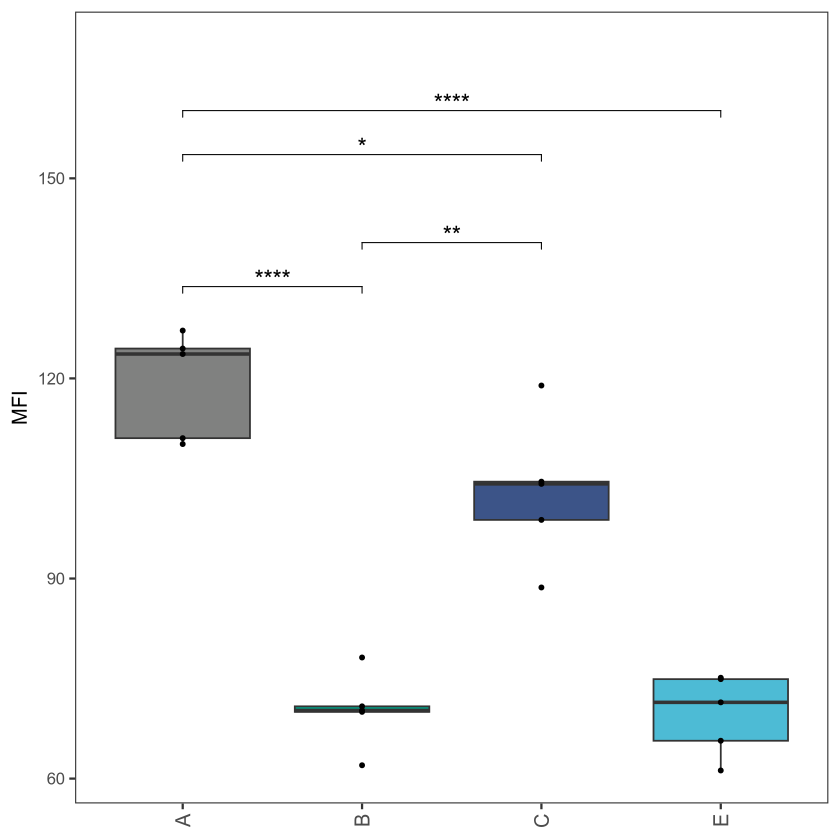

In [15]:
# Make subset of mfi called mf_subset that does not have dID subset
mf_subset <- mfi[mfi$Setup != "dID", ]
mf_subset$Setup <- factor(mf_subset$Setup,
                           levels = c("mock", "Runx3-WT", "dAD", "dVWRPY"))

# Calculate p-values and BH-adjusted p-values for comparisons using plot_padj function
plot.stat.df <- plot_padj(
    data = mf_subset,
    comparisons = list(
        c("mock", "Runx3-WT"),
        c("Runx3-WT", "dAD"),
        c("Runx3-WT", "dVWRPY"),
        c("mock", "dAD"),
        c("mock", "dVWRPY")
    ),
    y_col = "Tbet",
    x_col = "Setup",
    paired = FALSE,
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2022-037-Runx3mut-Tbet-stats.csv", row.names = FALSE)

# Only the significant comparisons get a bracket drawn (see
# stat_pvalue_manual below), so only these need extra headroom
plot.stat.sig <- plot.stat.df %>% filter(p.adj < 0.05)

p <- ggplot(mf_subset, aes(x = Setup, y = Tbet, fill = Setup)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size = 1) +
    scale_fill_manual(values = colors) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
    stat_pvalue_manual(
        plot.stat.sig,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    scale_x_discrete(labels = c("mock" = "A", 
                                "Runx3-WT" = "B", 
                                "dAD" = "C", 
                                "dID" = "D", 
                                "dVWRPY" = "E")) +
    ylab("MFI") +
    theme


print(p)

In [16]:
pdf("Tbet.pdf" , width = 2, height = 2.5)
print(p)
dev.off()

pdf 
  2